In [97]:
import pandas as pd

df = pd.read_csv("diabetes new dataset.csv")

# Basic info
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Mid,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               6000 non-null   int64  
 1   Glucose                   5400 non-null   float64
 2   BloodPressure             5400 non-null   float64
 3   SkinThickness             5400 non-null   float64
 4   Insulin                   5400 non-null   float64
 5   BMI                       5400 non-null   float64
 6   DiabetesPedigreeFunction  6000 non-null   float64
 7   Age                       6000 non-null   float64
 8   Outcome                   6000 non-null   int64  
 9   BMI_Category              6000 non-null   object 
 10  Age_Group                 6000 non-null   object 
 11  Glucose_Level             6000 non-null   object 
dtypes: float64(7), int64(2), object(3)
memory usage: 562.6+ KB


In [99]:
df.isnull().sum()

Pregnancies                   0
Glucose                     600
BloodPressure               600
SkinThickness               600
Insulin                     600
BMI                         600
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                  0
Age_Group                     0
Glucose_Level                 0
dtype: int64

In [100]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [101]:
df['Insulin'].describe()

count    5400.000000
mean      135.953069
std        21.365675
min        61.840956
25%       121.719285
50%       135.844838
75%       150.184380
max       225.161865
Name: Insulin, dtype: float64

In [102]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Mid,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,120.686254,109.388316,38.141407,138.210739,34.516049,0.258832,37.057632,0,Obese,Adult,Prediabetes
5996,2,118.503965,88.419612,34.813478,120.022208,27.536625,0.893585,48.831777,1,Overweight,Mid,Prediabetes
5997,2,108.388973,70.893077,45.317985,119.342180,35.907998,0.153524,20.391154,1,Obese,Young,Prediabetes
5998,2,111.119231,87.618313,37.901339,151.125654,30.020068,2.287700,40.615405,1,Obese,Mid,Prediabetes


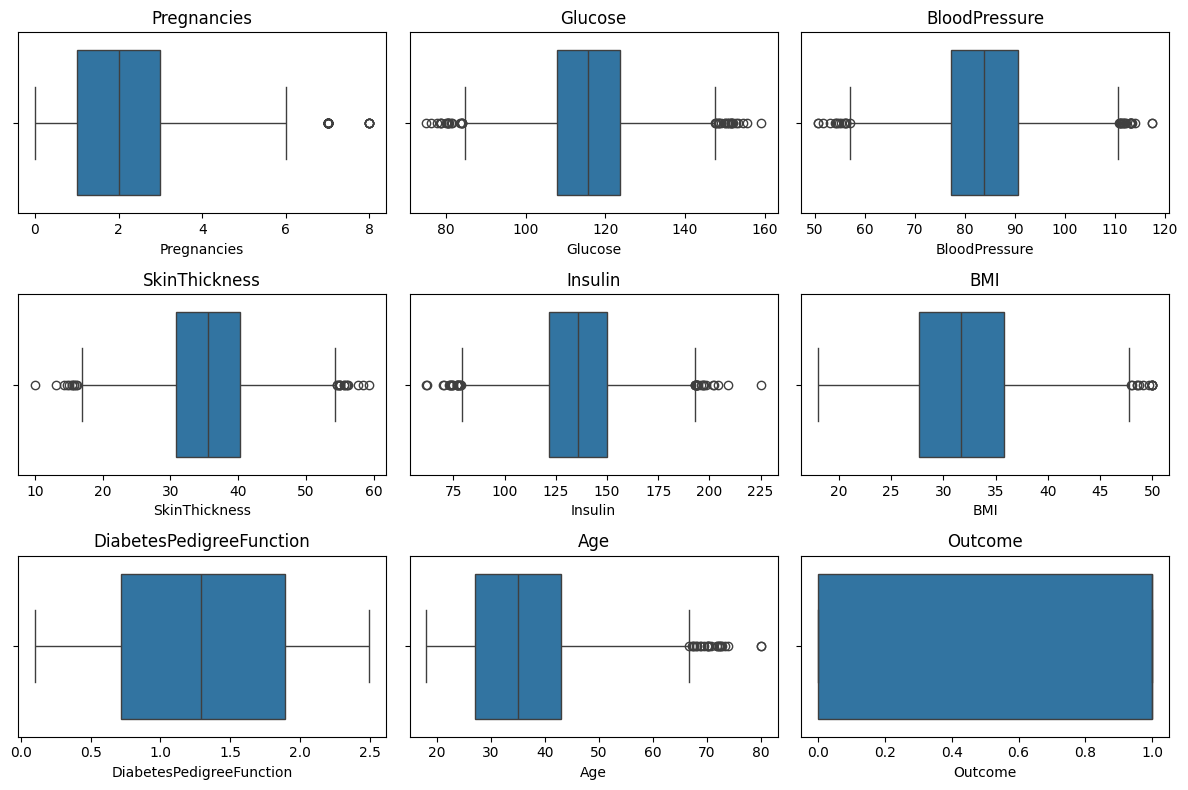

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)   # 3 rows, 3 columns (adjust if needed)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [104]:
num_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [105]:
df['BMI_Category'] = pd.cut(df['BMI'],
                           bins=[0,18.5,24.9,29.9,100],
                           labels=['Underweight','Normal','Overweight','Obese'])

In [106]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[20,30,40,50,100],
                        labels=['Young','Adult','Mid-age','Senior'])

In [107]:
df['Outcome'] = df['Outcome'].fillna(df['Outcome'].mode()[0])

In [108]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid-age,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid-age,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Senior,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,120.686254,109.388316,38.141407,138.210739,34.516049,0.258832,37.057632,0,Obese,Adult,Prediabetes
5996,2,118.503965,88.419612,34.813478,120.022208,27.536625,0.893585,48.831777,1,Overweight,Mid-age,Prediabetes
5997,2,108.388973,70.893077,45.317985,119.342180,35.907998,0.153524,20.391154,1,Obese,Young,Prediabetes
5998,2,111.119231,87.618313,37.901339,151.125654,30.020068,2.287700,40.615405,1,Obese,Mid-age,Prediabetes


In [109]:
int_cols = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'Age', 'Outcome']

df[int_cols] = df[int_cols].astype(int)

In [110]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                  0
Age_Group                   631
Glucose_Level                 0
dtype: int64

In [111]:
df['Glucose_Level'] = pd.cut(df['Glucose'],
                            bins=[0,99,125,200],
                            labels=['Normal','Prediabetic','Diabetic'])

In [112]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                  0
Age_Group                   631
Glucose_Level                 0
dtype: int64

In [113]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [114]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    print(col, (df[col] < 0).sum())

BMI 0
DiabetesPedigreeFunction 0


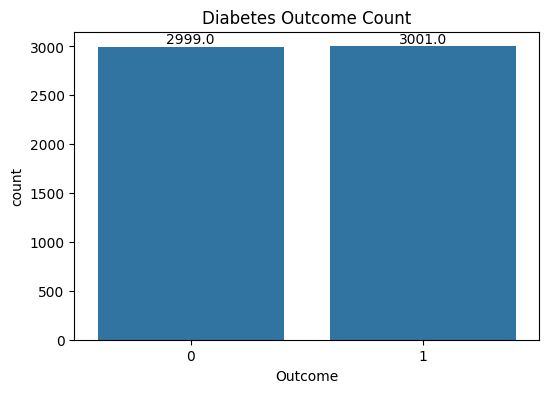

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Outcome', data=df)

# Add values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Diabetes Outcome Count")
plt.show()

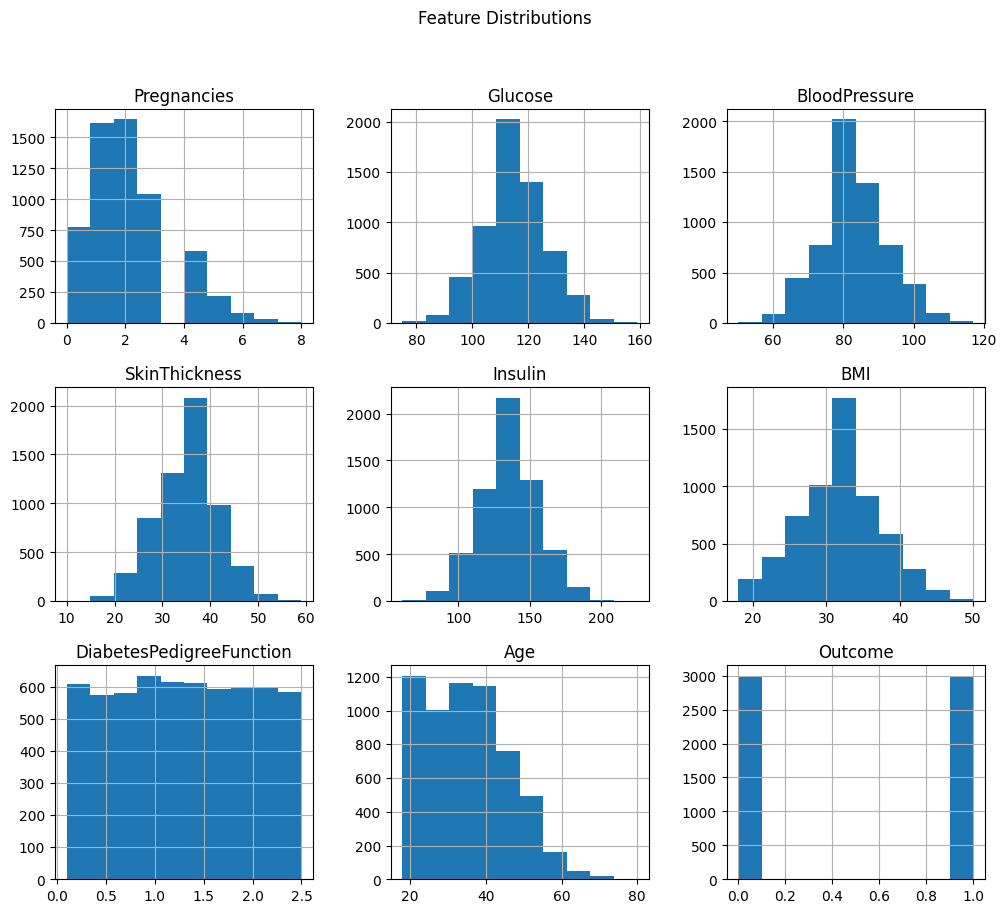

In [116]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

In [117]:
df.dtypes

Pregnancies                    int32
Glucose                        int32
BloodPressure                  int32
SkinThickness                  int32
Insulin                        int32
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int32
Outcome                        int32
BMI_Category                category
Age_Group                   category
Glucose_Level               category
dtype: object

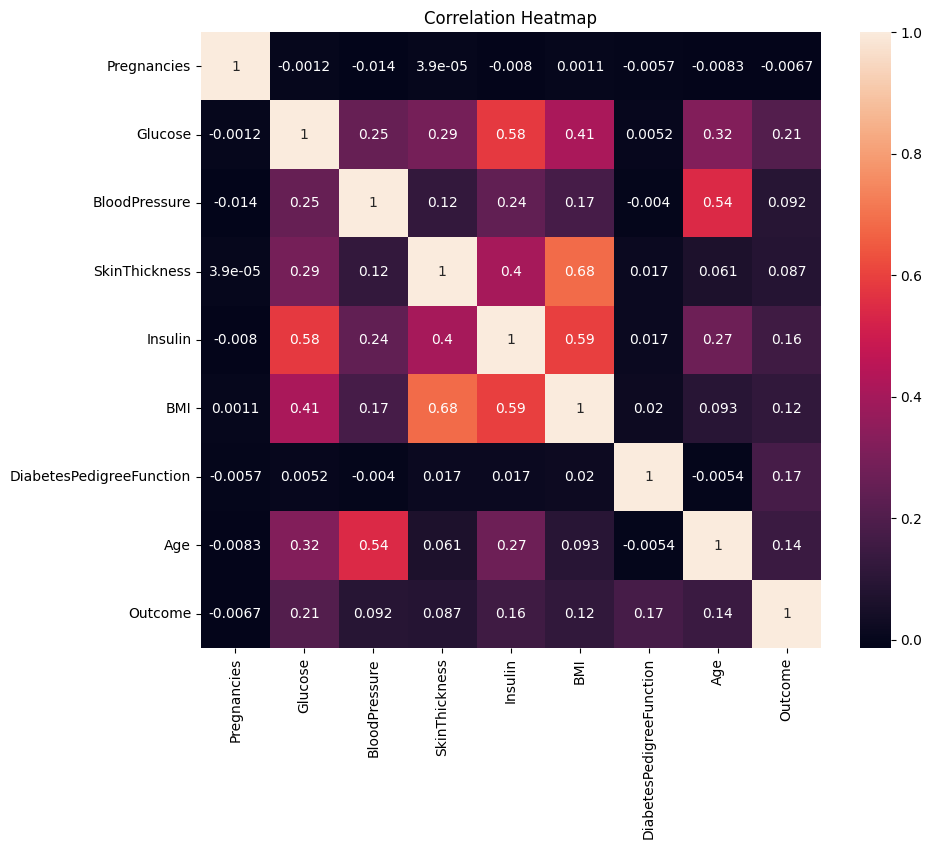

In [118]:
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=['int32','float64']).corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

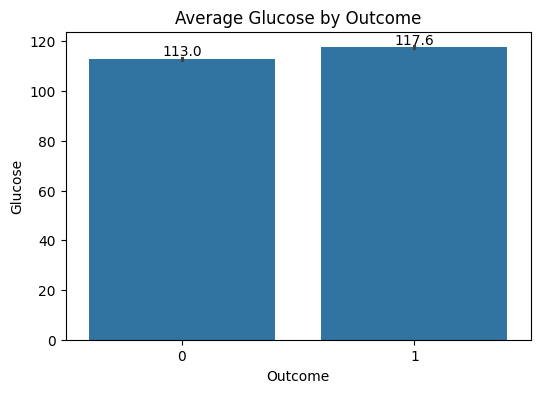

In [119]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x='Outcome', y='Glucose', data=df)

for p in ax.patches:
    ax.annotate(f'{round(p.get_height(),1)}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Average Glucose by Outcome")
plt.show()

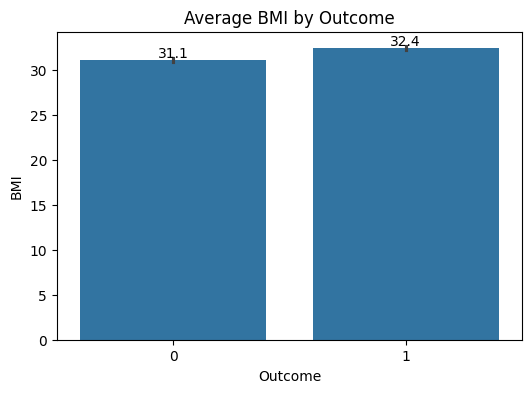

In [120]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x='Outcome', y='BMI', data=df)

for p in ax.patches:
    ax.annotate(f'{round(p.get_height(),1)}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Average BMI by Outcome")
plt.show()

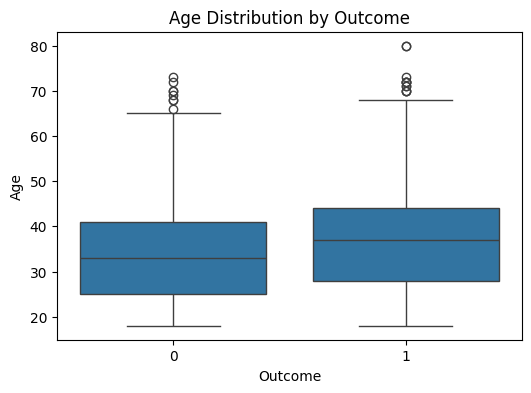

In [121]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Age', data=df)

plt.title("Age Distribution by Outcome")
plt.show()

In [126]:
# ==============================
# 1. IMPORT
# ==============================
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# 2. LOAD DATA
# ==============================
# ==============================
# 3. HANDLE MISSING VALUES
# ==============================
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=['Outcome'])

# ==============================
# 4. 🔥 FEATURE ENGINEERING
# ==============================
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Insulin_Glucose'] = df['Insulin'] * df['Glucose']
df['Age_BMI'] = df['Age'] * df['BMI']
df['BMI_Squared'] = df['BMI'] ** 2

# ==============================
# 5. ENCODING (FIXED 🔥)
# ==============================

# Detect BOTH object + category types
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", cat_cols)

# Apply encoding
if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ==============================
# 6. BALANCE DATA
# ==============================
df_majority = df[df['Outcome'] == 0]
df_minority = df[df['Outcome'] == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df = pd.concat([df_majority, df_minority_upsampled])

# ==============================
# 7. SPLIT
# ==============================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. 🔥 RANDOM FOREST (TUNED)
# ==============================
rf = RandomForestClassifier(
    n_estimators=150,        # ↓ from 600
    max_depth=12,            # limit depth
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ==============================
# 9. EVALUATION
# ==============================
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# 10. SAVE MODEL
# ==============================
pickle.dump(rf, open("diabetes_model.pkl", "wb"))
pickle.dump(X_train.columns.tolist(), open("columns.pkl", "wb"))

print("\n🔥 Final Random Forest model saved!")

Categorical columns: []
Accuracy: 0.8525

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85       609
           1       0.82      0.91      0.86       591

    accuracy                           0.85      1200
   macro avg       0.86      0.85      0.85      1200
weighted avg       0.86      0.85      0.85      1200


🔥 Final Random Forest model saved!
